<a href="https://colab.research.google.com/github/josephrich98/joseph_rich_blog/blob/main/posts/genomics-vs-nlp/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Genomics Is Not NLP — analysis notebook

This notebook reproduces the three figures in `main.md`. Every number is either
combinatorial (k-mer counting, $4^{-k}$), a published per-genome variation
statistic, or an illustrative simulation (the mRNA-protein scatter). Nothing here
requires downloading a genome. The final cell verifies that every cited DOI
resolves.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

FIG = "figures"
os.makedirs(FIG, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})

NAVY, CRIMSON, STEEL, AMBER = "#1f3b57", "#9b1d20", "#3d7ca6", "#d99a00"
GENOME_BP = 3.2e9  # haploid human genome, base pairs

## Figure 1 — the corpus is nearly one document

Two humans differ at $\sim 0.1\%$ of sites ($\pi \approx 0.001$), versus
$\sim 1.2\%$ human-chimp and essentially every token between two unrelated texts.
And within one genome, structural variants are rare as *events* but dominate the
*bases* that differ ($\sim 20$ Mb; Sudmant et al. 2015).

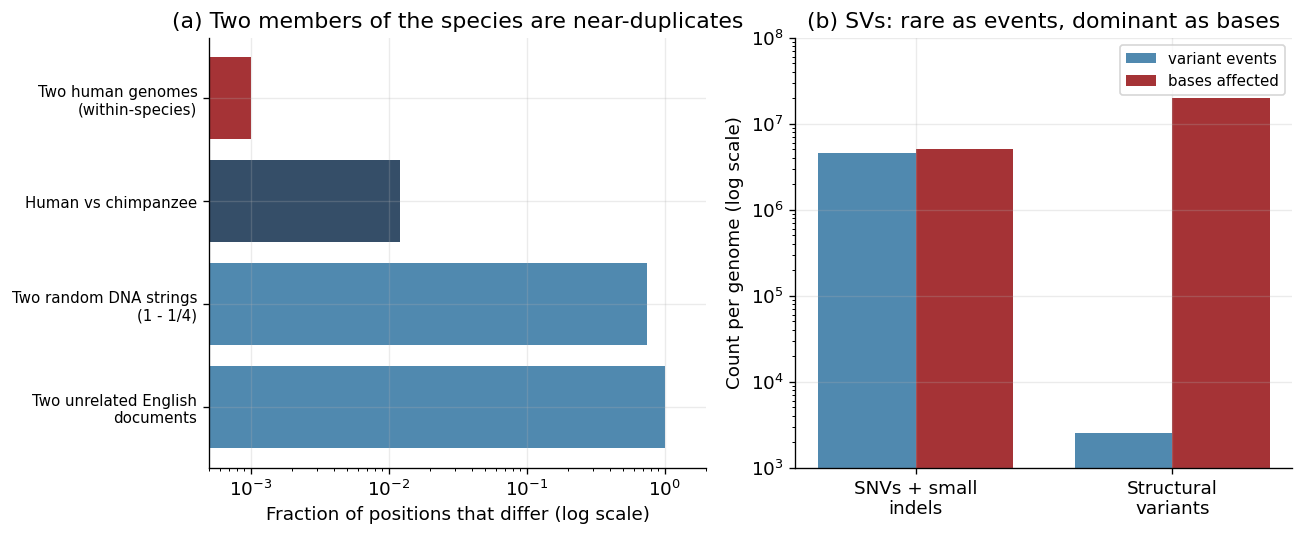

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

items = [
    ("Two human genomes\n(within-species)", 1.0e-3, CRIMSON),
    ("Human vs chimpanzee", 1.2e-2, NAVY),
    ("Two random DNA strings\n(1 - 1/4)", 0.75, STEEL),
    ("Two unrelated English\ndocuments", 1.0, STEEL),
]
labels = [i[0] for i in items]; fracs = np.array([i[1] for i in items]); colors = [i[2] for i in items]
y = np.arange(len(items))[::-1]
axes[0].barh(y, fracs, color=colors, alpha=0.9)
axes[0].set_xscale("log"); axes[0].set_yticks(y); axes[0].set_yticklabels(labels, fontsize=9)
axes[0].set_xlim(5e-4, 2.0); axes[0].set_xlabel("Fraction of positions that differ (log scale)")
axes[0].set_title("(a) Two members of the species are near-duplicates")

classes = ["SNVs + small\nindels", "Structural\nvariants"]
events = np.array([4.5e6, 2.5e3]); bases = np.array([5.0e6, 2.0e7])
x = np.arange(len(classes)); w = 0.38
axes[1].bar(x - w/2, events, w, color=STEEL, alpha=0.9, label="variant events")
axes[1].bar(x + w/2, bases, w, color=CRIMSON, alpha=0.9, label="bases affected")
axes[1].set_yscale("log"); axes[1].set_xticks(x); axes[1].set_xticklabels(classes)
axes[1].set_ylabel("Count per genome (log scale)"); axes[1].set_ylim(1e3, 1e8)
axes[1].legend(fontsize=9, loc="upper right"); axes[1].set_title("(b) SVs: rare as events, dominant as bases")

fig.tight_layout(); fig.savefig(os.path.join(FIG, "corpus_redundancy.png")); plt.show()

## Figure 2 — similarity beyond chance

Under an i.i.d.-uniform-base null, a specific $k$-mer occurs $G\cdot 4^{-k}$ times
in a genome of $G$ bases. This crosses 1 near $k \approx 16$ and is
$\approx 7\times 10^{-10}$ at $k = 31$ — so shared long $k$-mers are homology, not
coincidence.

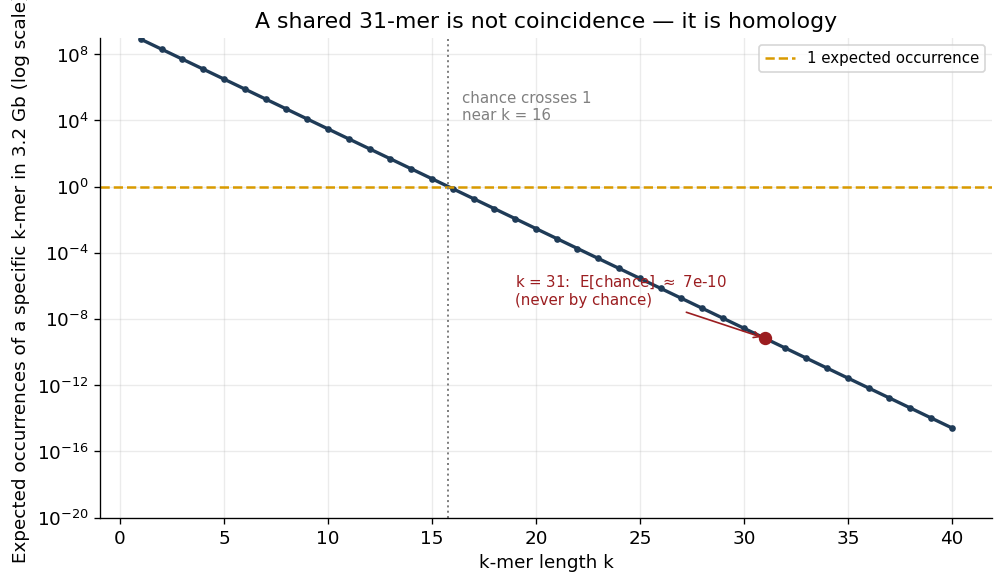

chance crosses 1 near k = 15.79; E[occurrences | k=31] = 6.94e-10


In [3]:
k = np.arange(1, 41)
expected = GENOME_BP * (4.0 ** (-k.astype(float)))
k_star = np.log(GENOME_BP) / np.log(4.0)
e31 = GENOME_BP * 4.0 ** (-31)

fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.plot(k, expected, color=NAVY, lw=2, marker="o", ms=3)
ax.set_yscale("log")
ax.axhline(1.0, color=AMBER, ls="--", lw=1.5, label="1 expected occurrence")
ax.axvline(k_star, color="grey", ls=":", lw=1.2)
ax.annotate(f"chance crosses 1\nnear k = {k_star:.0f}", (k_star, 1),
            textcoords="offset points", xytext=(8, 40), fontsize=9, color="grey")
ax.plot([31], [e31], "o", color=CRIMSON, ms=7)
ax.annotate(f"k = 31:  E[chance] $\\approx$ {e31:.0e}\n(never by chance)", (31, e31),
            textcoords="offset points", xytext=(-150, 20), fontsize=9, color=CRIMSON,
            arrowprops=dict(arrowstyle="->", color=CRIMSON, lw=1))
ax.set_xlabel("k-mer length k")
ax.set_ylabel("Expected occurrences of a specific k-mer in 3.2 Gb (log scale)")
ax.set_title("A shared 31-mer is not coincidence — it is homology")
ax.legend(fontsize=9, loc="upper right"); ax.set_ylim(1e-20, 1e9)
fig.tight_layout(); fig.savefig(os.path.join(FIG, "kmer_chance.png")); plt.show()
print(f"chance crosses 1 near k = {k_star:.2f}; E[occurrences | k=31] = {e31:.2e}")

## Figure 3 — the proxy problem and the multiple-testing tax

(a) Even at an mRNA-protein Spearman in the empirical $0.4$-$0.6$ range, fixing the
mRNA leaves protein spread over a wide band. (b) Uncorrected expected false
positives $= m\alpha$ grow with the number of tests $m$ — hence genome-wide
significance near $5\times 10^{-8}$.

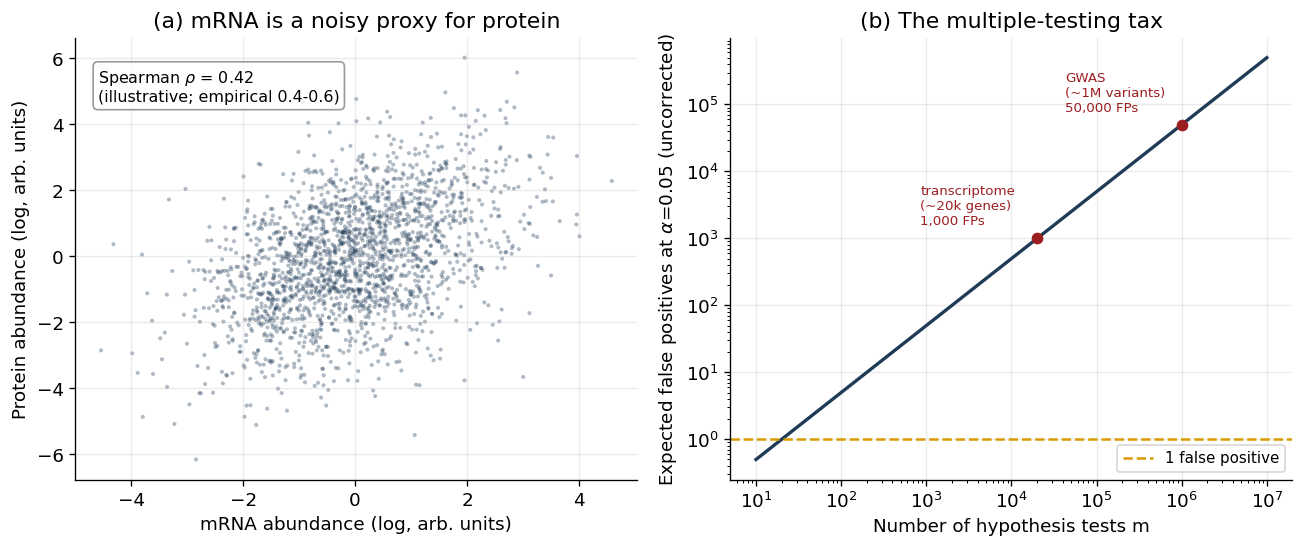

Spearman(mRNA, protein) = 0.425
uncorrected FPs: transcriptome=1000, GWAS=50000
Bonferroni genome-wide threshold = 0.05/1e6 = 5e-08


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.7))

rng = np.random.default_rng(7)
n = 2000
z = rng.standard_normal(n)
log_mrna = z + 0.9 * rng.standard_normal(n)
log_prot = z + 1.4 * rng.standard_normal(n)
rho, _ = spearmanr(log_mrna, log_prot)
axes[0].scatter(log_mrna, log_prot, s=6, color=NAVY, alpha=0.35, edgecolors="none")
axes[0].set_xlabel("mRNA abundance (log, arb. units)")
axes[0].set_ylabel("Protein abundance (log, arb. units)")
axes[0].set_title("(a) mRNA is a noisy proxy for protein")
axes[0].text(0.04, 0.93, f"Spearman $\\rho$ = {rho:.2f}\n(illustrative; empirical 0.4-0.6)",
             transform=axes[0].transAxes, va="top", fontsize=9.5,
             bbox=dict(boxstyle="round", fc="white", ec="grey", alpha=0.8))

m = np.logspace(1, 7, 300); alpha = 0.05
axes[1].plot(m, m * alpha, color=NAVY, lw=2)
axes[1].axhline(1.0, color=AMBER, ls="--", lw=1.5, label="1 false positive")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("Number of hypothesis tests m")
axes[1].set_ylabel(r"Expected false positives at $\alpha$=0.05 (uncorrected)")
axes[1].set_title("(b) The multiple-testing tax")
for mv, name in [(2e4, "transcriptome\n(~20k genes)"), (1e6, "GWAS\n(~1M variants)")]:
    axes[1].plot([mv], [mv * alpha], "o", color=CRIMSON)
    axes[1].annotate(f"{name}\n{mv*alpha:,.0f} FPs", (mv, mv * alpha),
                     textcoords="offset points", xytext=(-70, 8), fontsize=8, color=CRIMSON)
axes[1].legend(fontsize=9, loc="lower right")
fig.tight_layout(); fig.savefig(os.path.join(FIG, "proxy_and_testing.png")); plt.show()
print(f"Spearman(mRNA, protein) = {rho:.3f}")
print(f"uncorrected FPs: transcriptome={2e4*0.05:.0f}, GWAS={1e6*0.05:.0f}")
print(f"Bonferroni genome-wide threshold = 0.05/1e6 = {0.05/1e6:.0e}")

## Figure 4 — the unit of meaning lives on a different scale

A second reason genomics is not NLP: the atomic unit differs by orders of
magnitude. In English text the token is a *word* — typically $4$-$5$ characters.
In a genome the comparable functional unit is a *gene*, whose genomic span
(exons plus introns) runs to tens of thousands of bases, with a long tail into
the megabases ($\sim 2.4\,\mathrm{Mb}$ for dystrophin). The two distributions
below are illustrative — English word lengths from a representative per-token
length distribution, gene spans from a log-normal with a human-realistic median
($\approx 24\,\mathrm{kb}$) — but the separation is the point: the densities
barely share an axis, so the linguistic intuition that a "token" is a short,
bounded string does not transfer. Note the shared $x$-axis is logarithmic.</cell id="abfd6a64">

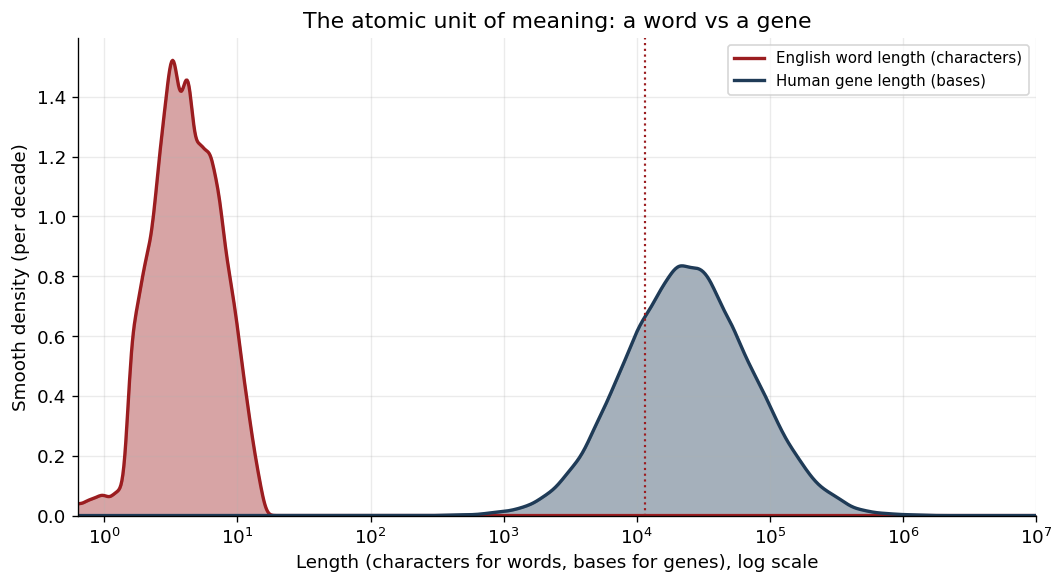

median word length = 4.1 characters; median gene span = 23,918 bases


In [ ]:
from scipy.stats import gaussian_kde

rng = np.random.default_rng(11)

# English word length (per running-text token): representative length distribution
# for lengths 1..15 characters (mean ~4.7). Word length is integer-valued, so we
# spread each count across its unit-width bin (+/- 0.5) to get a smooth density
# rather than a spike at every integer.
word_len = np.arange(1, 16)
word_pmf = np.array([0.027, 0.174, 0.207, 0.157, 0.107, 0.087, 0.070,
                     0.050, 0.037, 0.028, 0.018, 0.013, 0.0085, 0.005, 0.003])
word_pmf = word_pmf / word_pmf.sum()
word_samples = rng.choice(word_len, size=40000, p=word_pmf).astype(float)
word_samples += rng.uniform(-0.5, 0.5, size=word_samples.size)
word_samples = np.clip(word_samples, 0.5, None)

# Human protein-coding gene span (genomic, exons + introns): log-normal with a
# human-realistic median (~24 kb) and a long heavy tail toward the megabases.
gene_samples = rng.lognormal(mean=np.log(24_000), sigma=1.1, size=40000)

# Smooth densities are estimated in log10 space because gene length spans many
# orders of magnitude; a linear-space KDE would be dominated by the tail.
log_words = np.log10(word_samples)
log_genes = np.log10(gene_samples)
kde_w, kde_g = gaussian_kde(log_words), gaussian_kde(log_genes)

xs = np.linspace(-0.2, 7.0, 1000)          # 10^-0.2 (~0.6) to 10^7 (10 Mb)
dw, dg = kde_w(xs), kde_g(xs)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(xs, dw, color=CRIMSON, alpha=0.40)
ax.plot(xs, dw, color=CRIMSON, lw=2, label="English word length (characters)")
ax.fill_between(xs, dg, color=NAVY, alpha=0.40)
ax.plot(xs, dg, color=NAVY, lw=2, label="Human gene length (bases)")

# Median markers.
mw, mg = np.median(word_samples), np.median(gene_samples)
for med, c in [(mw, CRIMSON), (mg, NAVY)]:
    ax.axvline(np.log10(med), color=c, ls=":", lw=1.3)

ax.set_xticks(range(0, 8))
ax.set_xticklabels([f"$10^{{{t}}}$" for t in range(0, 8)])
ax.set_xlim(-0.2, 7.0)
ax.set_ylim(bottom=0)
ax.set_xlabel("Length (characters for words, bases for genes), log scale")
ax.set_ylabel("Smooth density (per decade)")
ax.set_title("The atomic unit of meaning: a word vs a gene")
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout(); fig.savefig(os.path.join(FIG, "unit_length_scales.png")); plt.show()
print(f"median word length = {mw:.1f} characters; median gene span = {mg:,.0f} bases")
# print(f"ratio of medians ~ {mg/mw:,.0f}x ({np.log10(mg/mw):.1f} orders of magnitude)")</cell id="52c24997">